In [1]:
# Install required libraries
!pip install pandas matplotlib seaborn -q

# Import all libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


Uploading & Loading Data

In [3]:
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1', parse_dates=['Order Date', 'Ship Date'])

print("✅ Data loaded!")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(df.head(3))

✅ Data loaded!
Rows: 9,994  |  Columns: 21
   Row ID        Order ID Order Date  Ship Date     Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11  Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11  Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16  Second Class    DV-13045   

     Customer Name    Segment        Country         City  ... Postal Code  \
0      Claire Gute   Consumer  United States    Henderson  ...       42420   
1      Claire Gute   Consumer  United States    Henderson  ...       42420   
2  Darrin Van Huff  Corporate  United States  Los Angeles  ...       90036   

   Region       Product ID         Category Sub-Category  \
0   South  FUR-BO-10001798        Furniture    Bookcases   
1   South  FUR-CH-10000454        Furniture       Chairs   
2    West  OFF-LA-10000240  Office Supplies       Labels   

                                        Product Name   Sales  Quantity  \
0                  B

Data Cleaning

In [6]:
# ── Checking missing values ──────────────────────────────────
print("=== Missing Values ===")
print(df.isnull().sum())

# ── Checking duplicate rows ──────────────────────────────────
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# ── Feature Engineering ───────────────────────────────────
# Extracting year from Order Date
df['Year'] = df['Order Date'].dt.year

# Extracting year-month for trend analysis
df['Month'] = df['Order Date'].dt.to_period('M').astype(str)

# Calculating how many days it took to ship each order
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Creating discount bands for grouping
df['Discount Band'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0, 0.1, 0.2, 0.3, 1.0],
    labels=['0%', '1-10%', '11-20%', '21-30%', '31%+']
)

print("\n✅ Cleaning done! New columns added: Year, Month, Ship Days, Discount Band")
print(df[['Order Date', 'Ship Date', 'Ship Days', 'Discount Band']].head(5))

=== Missing Values ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
Ship Days        0
Discount Band    0
dtype: int64

Duplicate rows: 0

✅ Cleaning done! New columns added: Year, Month, Ship Days, Discount Band
  Order Date  Ship Date  Ship Days Discount Band
0 2016-11-08 2016-11-11          3            0%
1 2016-11-08 2016-11-11          3            0%
2 2016-06-12 2016-06-16          4            0%
3 2015-10-11 2015-10-18          7          31%+
4 2015-10-11 2015-10-18          7        11-20%


Business Overview (EDA)

In [5]:
# ── Key Business Metrics ──────────────────────────────────
print("=" * 45)
print("       BUSINESS OVERVIEW")
print("=" * 45)
print(f"Total Unique Orders   : {df['Order ID'].nunique():,}")
print(f"Total Revenue         : ${df['Sales'].sum():,.2f}")
print(f"Total Profit          : ${df['Profit'].sum():,.2f}")
print(f"Profit Margin         : {df['Profit'].sum() / df['Sales'].sum() * 100:.2f}%")
print(f"Unique Customers      : {df['Customer ID'].nunique():,}")
print(f"Unique Products       : {df['Product Name'].nunique():,}")
print(f"Date Range            : {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")

       BUSINESS OVERVIEW
Total Unique Orders   : 5,009
Total Revenue         : $2,297,200.86
Total Profit          : $286,397.02
Profit Margin         : 12.47%
Unique Customers      : 793
Unique Products       : 1,850
Date Range            : 2014-01-03 → 2017-12-30


Deep Dive Analysis

In [7]:
# ── Revenue by Region ─────────────────────────────────────
print("=== Revenue & Profit by Region ===")
region_df = df.groupby('Region').agg(
    Revenue   = ('Sales', 'sum'),
    Profit    = ('Profit', 'sum'),
    Orders    = ('Order ID', 'nunique')
).sort_values('Revenue', ascending=False).round(2)
print(region_df)

# ── Revenue by Category ───────────────────────────────────
print("\n=== Revenue & Profit by Category ===")
cat_df = df.groupby('Category').agg(
    Revenue   = ('Sales', 'sum'),
    Profit    = ('Profit', 'sum'),
    Units     = ('Quantity', 'sum')
).sort_values('Revenue', ascending=False).round(2)
print(cat_df)

# ── Top 5 Products ────────────────────────────────────────
print("\n=== Top 5 Products by Revenue ===")
top5 = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(5).round(2)
print(top5)

# ── Discount Impact ───────────────────────────────────────
print("\n=== Discount Impact on Profit ===")
disc_df = df.groupby('Discount Band')['Profit'].agg(
    Avg_Profit  = 'mean',
    Total_Profit= 'sum',
    Count       = 'count'
).round(2)
print(disc_df)

# ── Customer Segment ──────────────────────────────────────
print("\n=== Customer Segment Performance ===")
seg_df = df.groupby('Segment').agg(
    Revenue  = ('Sales', 'sum'),
    Profit   = ('Profit', 'sum'),
    Orders   = ('Order ID', 'nunique'),
    Customers= ('Customer ID', 'nunique')
).sort_values('Revenue', ascending=False).round(2)
print(seg_df)

=== Revenue & Profit by Region ===
           Revenue     Profit  Orders
Region                               
West     725457.82  108418.45    1611
East     678781.24   91522.78    1401
Central  501239.89   39706.36    1175
South    391721.90   46749.43     822

=== Revenue & Profit by Category ===
                   Revenue     Profit  Units
Category                                    
Technology       836154.03  145454.95   6939
Furniture        741999.80   18451.27   8028
Office Supplies  719047.03  122490.80  22906

=== Top 5 Products by Revenue ===
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.82
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.38
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.48
HON 5400 Series Task Chairs for Big and Tall                                   21870.58
GBC DocuBind TL300 Electric Binding System                                

Chart 1: KPI Overview Cards

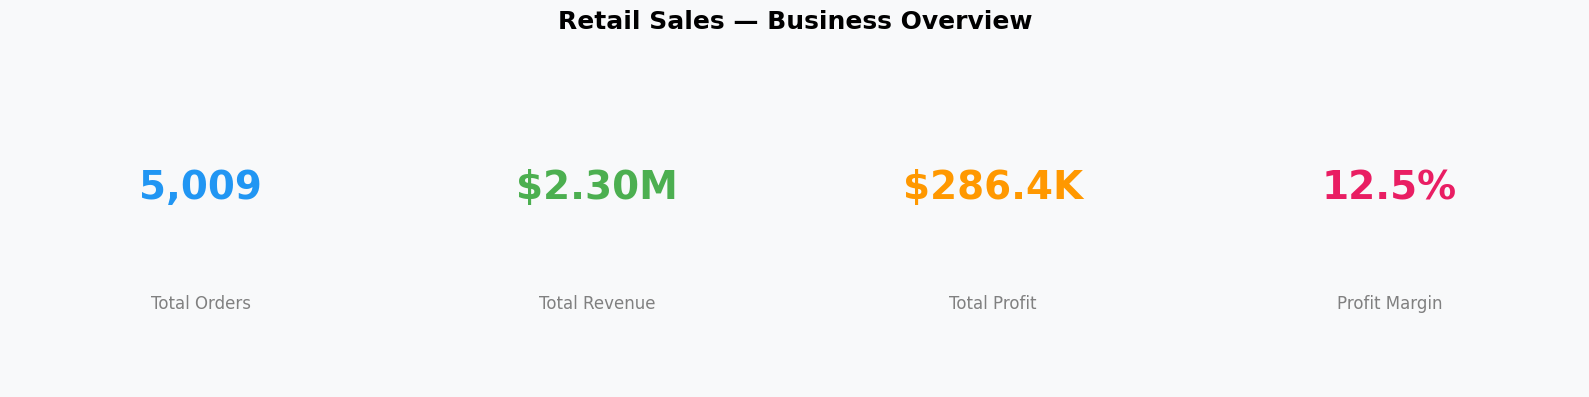

✅ Chart 1 saved!


In [8]:
# Set global chart style
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'figure.facecolor' : '#f8f9fa'
})
COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0', '#00BCD4']

# ── KPI Cards ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Retail Sales — Business Overview', fontsize=18, fontweight='bold')

kpis = [
    ('Total Orders',  f"{df['Order ID'].nunique():,}",                    '#2196F3'),
    ('Total Revenue', f"${df['Sales'].sum()/1e6:.2f}M",                   '#4CAF50'),
    ('Total Profit',  f"${df['Profit'].sum()/1e3:.1f}K",                  '#FF9800'),
    ('Profit Margin', f"{df['Profit'].sum()/df['Sales'].sum()*100:.1f}%", '#E91E63'),
]
for ax, (title, value, color) in zip(axes, kpis):
    ax.set_facecolor('white')
    ax.text(0.5, 0.6, value, ha='center', va='center',
            fontsize=28, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.25, title, ha='center', va='center',
            fontsize=12, color='gray', transform=ax.transAxes)
    ax.axis('off')

plt.tight_layout()
plt.savefig('chart1_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

Chart 2: Revenue by Region

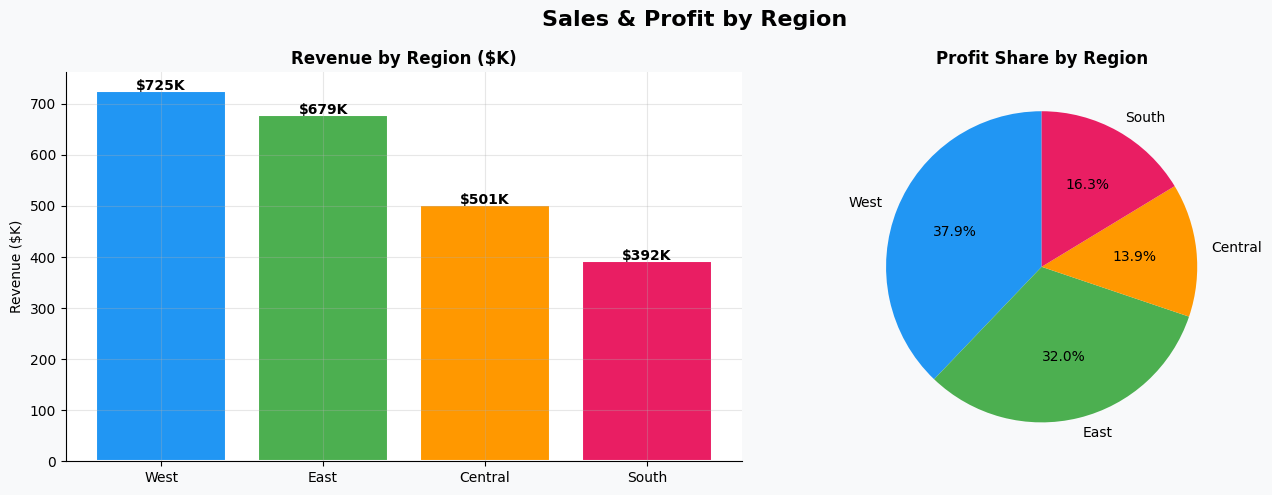

✅ Chart 2 saved!


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sales & Profit by Region', fontsize=16, fontweight='bold')

region_plot = region_df.reset_index().sort_values('Revenue', ascending=False)

# Bar chart — Revenue by region
bars = ax1.bar(region_plot['Region'], region_plot['Revenue']/1000, color=COLORS[:4], edgecolor='white', linewidth=1.5)
ax1.set_title('Revenue by Region ($K)', fontweight='bold')
ax1.set_ylabel('Revenue ($K)')
for bar, val in zip(bars, region_plot['Revenue']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'${val/1000:.0f}K', ha='center', fontsize=10, fontweight='bold')

# Pie chart — Profit share by region
ax2.pie(region_plot['Profit'], labels=region_plot['Region'],
        autopct='%1.1f%%', colors=COLORS[:4], startangle=90)
ax2.set_title('Profit Share by Region', fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

Chart 3: Sales by Category

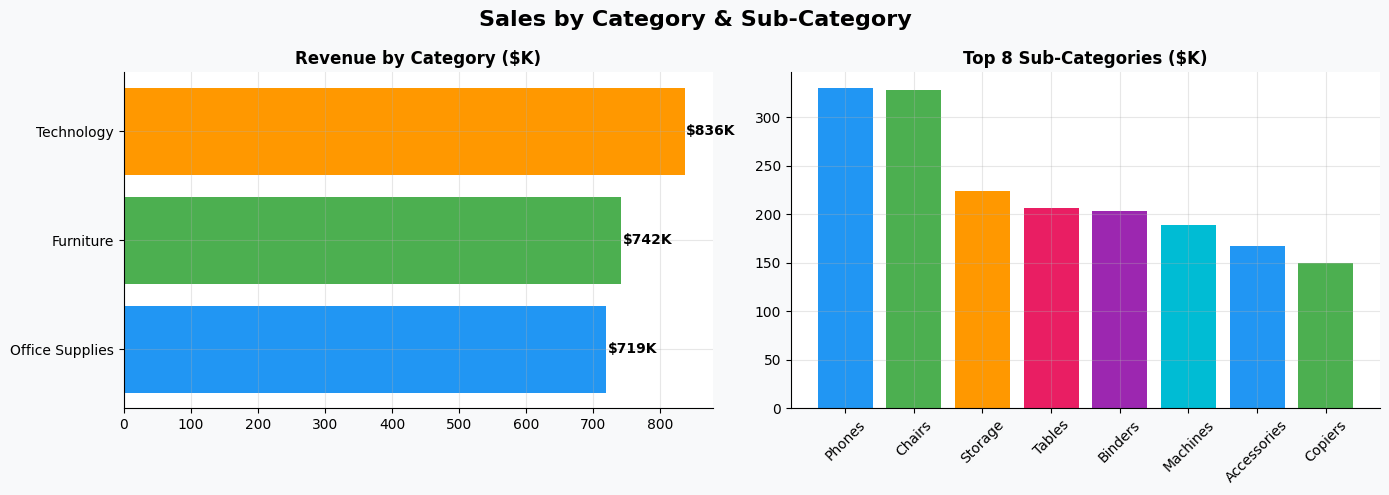

✅ Chart 3 saved!


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sales by Category & Sub-Category', fontsize=16, fontweight='bold')

cat_plot = cat_df.reset_index().sort_values('Revenue')

# Horizontal bar — Category revenue
ax1.barh(cat_plot['Category'], cat_plot['Revenue']/1000, color=COLORS[:3])
ax1.set_title('Revenue by Category ($K)', fontweight='bold')
for i, val in enumerate(cat_plot['Revenue']):
    ax1.text(val/1000 + 2, i, f'${val/1000:.0f}K', va='center', fontsize=10, fontweight='bold')

# Bar chart — Top 8 sub-categories
sub_df = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(8)
ax2.bar(sub_df.index, sub_df.values/1000, color=COLORS)
ax2.set_title('Top 8 Sub-Categories ($K)', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('chart3_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

Chart 4: Monthly Sales Trend

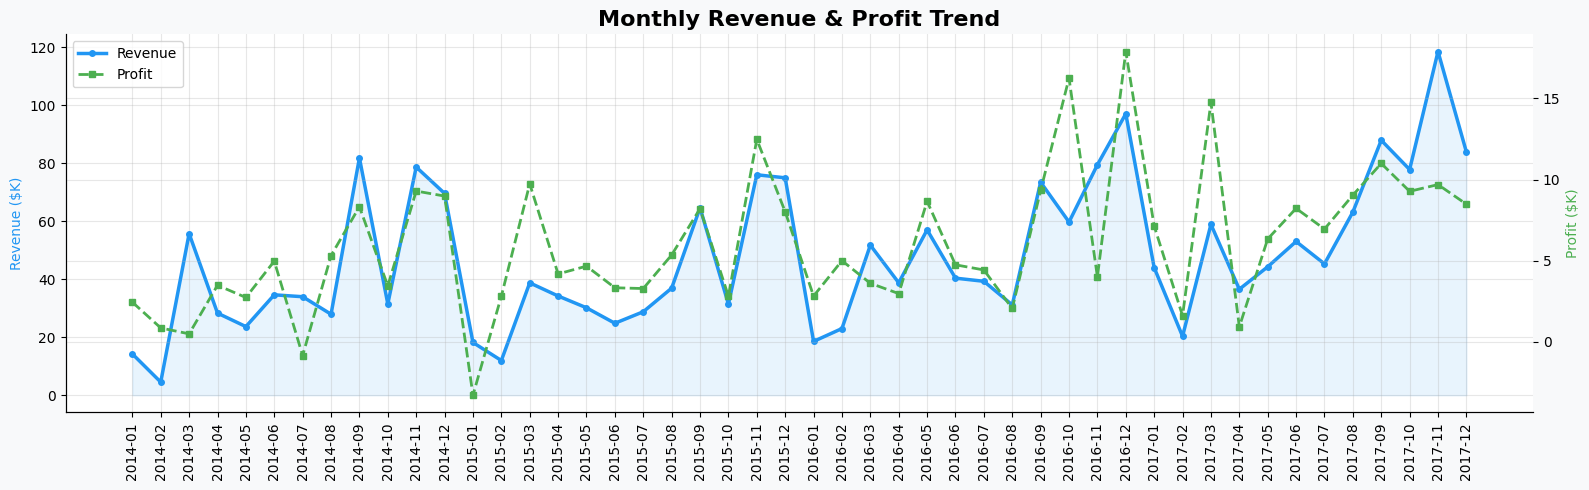

✅ Chart 4 saved!


In [11]:
fig, ax1 = plt.subplots(figsize=(16, 5))
fig.patch.set_facecolor('#f8f9fa')

# Aggregate monthly data
monthly = df.groupby('Month').agg(
    Revenue = ('Sales', 'sum'),
    Profit  = ('Profit', 'sum')
).reset_index()

# Revenue line on left axis
ax1.plot(monthly['Month'], monthly['Revenue']/1000,
         color='#2196F3', linewidth=2.5, marker='o', markersize=4, label='Revenue')
ax1.fill_between(monthly['Month'], monthly['Revenue']/1000, alpha=0.1, color='#2196F3')
ax1.set_ylabel('Revenue ($K)', color='#2196F3')
ax1.tick_params(axis='x', rotation=90)

# Profit line on right axis
ax2 = ax1.twinx()
ax2.plot(monthly['Month'], monthly['Profit']/1000,
         color='#4CAF50', linewidth=2, linestyle='--', marker='s', markersize=4, label='Profit')
ax2.set_ylabel('Profit ($K)', color='#4CAF50')

ax1.set_title('Monthly Revenue & Profit Trend', fontsize=16, fontweight='bold')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('chart4_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

Chart 5: Discount Impact

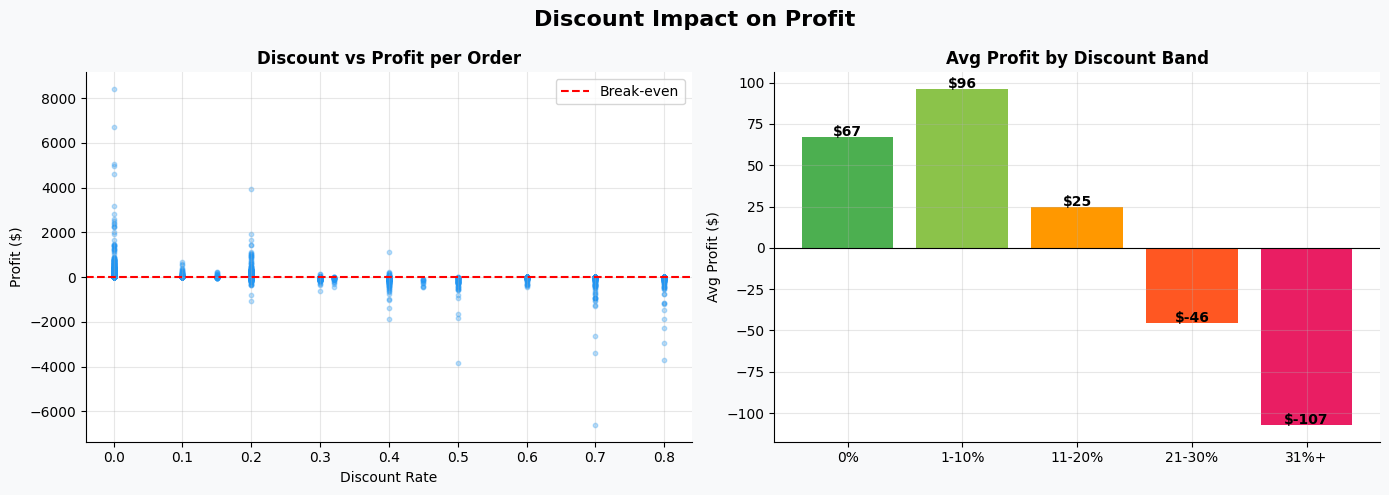

✅ Chart 5 saved!


In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Discount Impact on Profit', fontsize=16, fontweight='bold')

# Scatter — every order plotted: discount vs profit
ax1.scatter(df['Discount'], df['Profit'], alpha=0.3, color='#2196F3', s=10)
ax1.axhline(0, color='red', linestyle='--', linewidth=1.5, label='Break-even')
ax1.set_title('Discount vs Profit per Order', fontweight='bold')
ax1.set_xlabel('Discount Rate')
ax1.set_ylabel('Profit ($)')
ax1.legend()

# Bar — avg profit per discount band
disc_plot = df.groupby('Discount Band')['Profit'].mean().reset_index()
bar_colors = ['#4CAF50', '#8BC34A', '#FF9800', '#FF5722', '#E91E63']
ax2.bar(disc_plot['Discount Band'], disc_plot['Profit'], color=bar_colors)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Avg Profit by Discount Band', fontweight='bold')
ax2.set_ylabel('Avg Profit ($)')
for i, val in enumerate(disc_plot['Profit']):
    ax2.text(i, val + 0.5, f'${val:.0f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('chart5_discount.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

Chart 6: Customer Segment

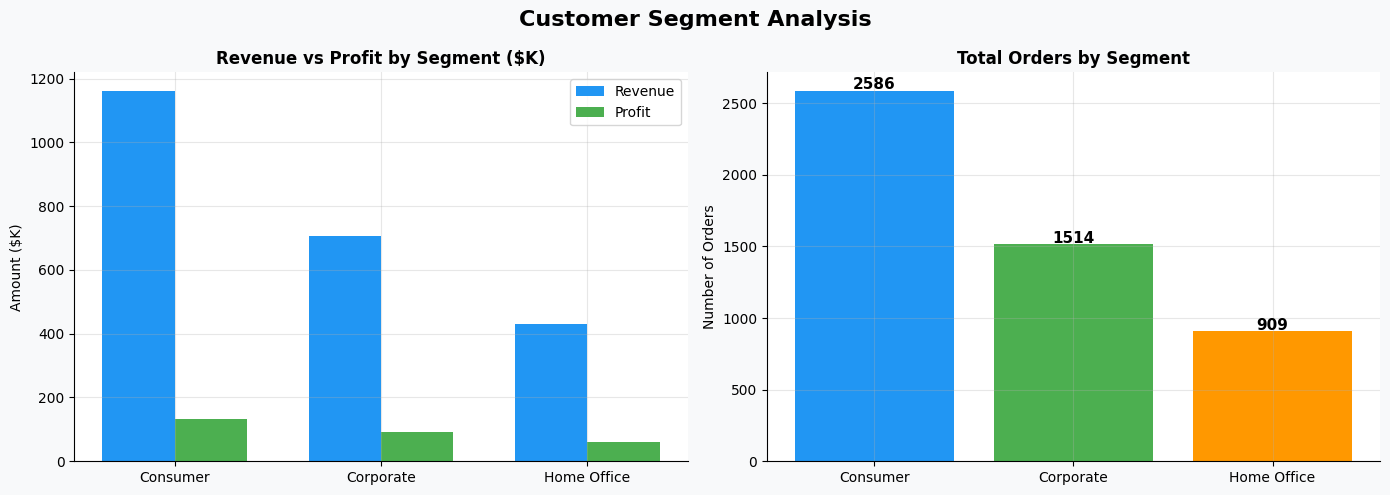

✅ Chart 6 saved!


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Segment Analysis', fontsize=16, fontweight='bold')

seg_plot = seg_df.reset_index()
x = range(len(seg_plot))

# Grouped bar — Revenue vs Profit
ax1.bar([i - 0.175 for i in x], seg_plot['Revenue']/1000, 0.35, label='Revenue', color='#2196F3')
ax1.bar([i + 0.175 for i in x], seg_plot['Profit']/1000,  0.35, label='Profit',  color='#4CAF50')
ax1.set_xticks(x)
ax1.set_xticklabels(seg_plot['Segment'])
ax1.set_title('Revenue vs Profit by Segment ($K)', fontweight='bold')
ax1.set_ylabel('Amount ($K)')
ax1.legend()

# Bar — Total orders per segment
ax2.bar(seg_plot['Segment'], seg_plot['Orders'], color=COLORS[:3])
ax2.set_title('Total Orders by Segment', fontweight='bold')
ax2.set_ylabel('Number of Orders')
for i, val in enumerate(seg_plot['Orders']):
    ax2.text(i, val + 10, str(val), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('chart6_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved!")